# lab2：Обработка кардиологического датасета для решения задач бинарной классификации.

In [9]:

!pip install pandas numpy scikit-learn flaml matplotlib

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
from flaml import AutoML

In [11]:
!git clone https://github.com/AI-is-out-there/data2lab.git
!ls data2lab

df = pd.read_csv('data2lab/модуль 2 - датасет - практика.csv', encoding='utf-8')
df = df.sample(5000, random_state=42)
df.head()

Cloning into 'data2lab'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 507.65 KiB | 3.57 MiB/s, done.
Resolving deltas: 100% (1/1), done.
 README.md
'модуль 2 - датасет - практика.csv'
'модуль 2 - описание столбцов данных ЭКГ.pdf'
'модуль 3 - датасет - практика.csv'


,subject_id,Count_subj,study_id,cart_id,Healthy_Status,eeg_time,eeg_date,report_0,report_1,report_2,...,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis
6252,14673266,69,40079688,6228136,1,2:08 PM,14.05.2011,Sinus rhythm,NaN,Normal ECG,...,60 Hz notch Baseline filter,923,40,132,192,268,602,-2,-19,51
4684,12343212,5,40059943,6833291,0,10:19 AM,24.01.2010,Sinus rhythm,Short PR interval,Long QTc interval,...,60 Hz notch Baseline filter,833,40,120,132,224,598,64,-39,-144
1731,19169704,10,40022355,6903271,0,3:20 AM,01.04.2013,Atrial fibrillation with rapid ventricular res...,NaN,Abnormal ECG,...,Baseline filter,526,29999,29999,200,282,502,29999,1,34
4742,12970863,12,40060644,6920139,0,7:34 AM,28.05.2013,Sinus rhythm,Lateral ST-T changes may be due to myocardial ...,NaN,...,60 Hz notch Baseline filter,857,40,156,226,326,644,58,-2,135
4521,18847661,12,40057727,6623967,0,4:07 AM,19.05.2012,Sinus rhythm with borderline 1st degree A-V block,Poor R wave progression - probable normal variant,Low QRS voltages in precordial leads,...,60 Hz notch Baseline filter,983,40,166,244,336,684,25,4,8


In [12]:
cols = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']
data = df[cols]
X = data.drop('Healthy_Status', axis=1)
y = data['Healthy_Status']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
automl = AutoML()
automl.fit(X_train=X_train_scaled, y_train=y_train, task='classification', time_budget=300)

[flaml.automl.logger: 05-11 15:25:34] {2375} INFO - task = classification
[flaml.automl.logger: 05-11 15:25:34] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-11 15:25:34] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 05-11 15:25:34] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 05-11 15:25:34] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-11 15:25:35] {3046} INFO - Estimated sufficient time budget=7813s. Estimated necessary time budget=181s.
[flaml.automl.logger: 05-11 15:25:35] {3097} INFO -  at 0.8s,	estimator lgbm's best error=1.2193e-01,	best estimator lgbm's best error=1.2193e-01
[flaml.automl.logger: 05-11 15:25:35] {2911} INFO - iteration 1, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[flaml.automl.logger: 05-11 15:25:35] {3097} INFO -  at 1.0s,	estimator lgbm's best error=1.2193e-01,	best estimator lgbm's best error=1.2193e-01
[flaml.automl.logger: 05-11 15:25:35] {2911} INFO - iteration 2, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[flaml.automl.logger: 05-11 15:25:36] {3097} INFO -  at 1.2s,	estimator lgbm's best error=1.1911e-01,	best estimator lgbm's best error=1.1911e-01
[flaml.automl.logger: 05-11 15:25:36] {2911} INFO - iteration 3, current learner lgbm
[flaml.automl.logger: 05-11 15:25:36] {3097} INFO -  at 1.3s,	estimator lgbm's best error=9.9603e-02,	best estimator lgbm's best error=9.9603e-02
[flaml.automl.logger: 05-11 15:25:36] {2911} INFO - iteration 4, current learner lgbm


...

[flaml.automl.logger: 05-11 15:30:32] {3097} INFO -  at 298.0s,	estimator xgboost's best error=9.2869e-02,	best estimator xgboost's best error=9.2869e-02
[flaml.automl.logger: 05-11 15:30:32] {2911} INFO - iteration 392, current learner lgbm
[flaml.automl.logger: 05-11 15:30:33] {3097} INFO -  at 298.2s,	estimator lgbm's best error=9.3534e-02,	best estimator xgboost's best error=9.2869e-02
[flaml.automl.logger: 05-11 15:30:33] {2911} INFO - iteration 393, current learner xgboost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 05-11 15:30:33] {3097} INFO -  at 298.3s,	estimator xgboost's best error=9.2869e-02,	best estimator xgboost's best error=9.2869e-02
[flaml.automl.logger: 05-11 15:30:33] {2911} INFO - iteration 394, current learner xgboost
[flaml.automl.logger: 05-11 15:30:33] {3097} INFO -  at 298.6s,	estimator xgboost's best error=9.2869e-02,	best estimator xgboost's best error=9.2869e-02
[flaml.automl.logger: 05-11 15:30:33] {2911} INFO - iteration 395, current learner xgboost
[flaml.automl.logger: 05-11 15:30:33] {3097} INFO -  at 298.9s,	estimator xgboost's best error=9.2869e-02,	best estimator xgboost's best error=9.2869e-02
[flaml.automl.logger: 05-11 15:30:33] {2911} INFO - iteration 396, current learner xgboost
[flaml.automl.logger: 05-11 15:30:33] {3097} INFO -  at 299.0s,	estimator xgboost's best error=9.2869e-02,	best estimator xgboost's best error=9.2869e-02
[flaml.automl.logger: 05-11 15:30:33] {2911} INFO - iteration 397, current learner xgboost
[flaml.automl.logger

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 05-11 15:30:35] {3097} INFO -  at 300.5s,	estimator lrl1's best error=2.5409e-01,	best estimator xgboost's best error=9.2869e-02
[flaml.automl.logger: 05-11 15:30:35] {3359} INFO - retrain xgboost for 0.0s
[flaml.automl.logger: 05-11 15:30:35] {3362} INFO - retrained model: XGBClassifier(base_score=None, booster=None, callbacks=[],
              colsample_bylevel=np.float64(0.8116141245238658),
              colsample_bynode=None,
              colsample_bytree=np.float64(0.835026315378538), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy='lossguide', importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.22831879706194497), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=0, max_leaves=4,
          

In [16]:
y_pred = automl.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print('Confusion Matrix:', cm)
print('F1 Score:', f1)

Confusion Matrix: [[720  80]
 [ 66 134]]
F1 Score: 0.6473429951690821


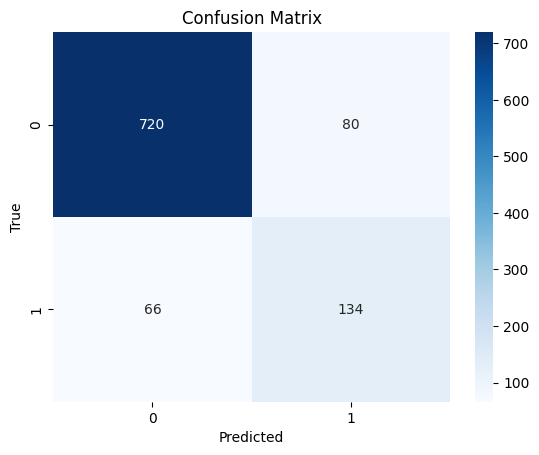

In [17]:
# confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


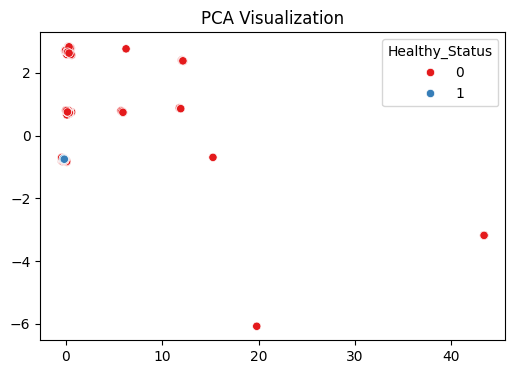

In [18]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled := scaler.fit_transform(X))
plt.figure(figsize=(6,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1')
plt.title('PCA Visualization')
plt.show()

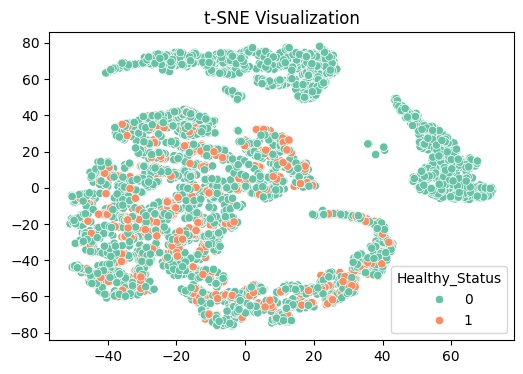

In [19]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
plt.figure(figsize=(6,4))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='Set2')
plt.title('t-SNE Visualization')
plt.show()